In [8]:
import matplotlib
%matplotlib inline
import matplotlib.pyplot as plt

import numpy as np
import torch
import torch.optim
from flonacomldft.utils.data_utils import (
    load_from_pickle, load_zmat_csv, load_csv_file, get_path, 
)
from flonacomldft.internal_coordinates import get_mix_data
from flonacomldft.utils.silver_isomers_utils import get_molecule_isomer_minima
from flonacomldft.utils.visualize import plotting_fes_db
# from flonacomldft.models import Uncentered_MLP
# from flonacomldft.mixture import Mixture, get_models
# from flonacomldft.dft_utils import Structure
# from flonacomldft.internal_coordinates import Angles_mapping

In [3]:
data_path = get_path()
data_path

'/Users/marylou/Dropbox/Prof/Experiments/_ceph/ml-dft/database/'

In [4]:
data_is1 = load_zmat_csv("is1")
data_is2 = load_zmat_csv("is2")

xis, uis, cis = get_mix_data(data_is1, data_is2)

# Pretrain mlps and flows

# loading pretrain mlps models
mlp_is1 = load_from_pickle(get_path() + "mlp_is1")
mlp_is2 = load_from_pickle(get_path() + "mlp_is2")

# loading pretrain flows models
nf_is1 = load_from_pickle(get_path() + "training_is1")
nf_is2 = load_from_pickle(get_path() + "training_is2")

In [6]:
xis.shape, uis.shape, cis.shape

(torch.Size([10002, 12]), torch.Size([10002]), torch.Size([10002]))

In [5]:
# plotting_fes_db()

RuntimeError: Path to points_cvsLCAO.dat not understood

In [77]:
n_steps = 5000

loss_fn = lambda x: mlp_is1.predict(x)

# start_indx = -3
start_indx = -4
assert cis[start_indx] == 0
x = xis[start_indx].requires_grad_(True)
print(x.clone())

optimizer = torch.optim.Adam([x,], lr=1e-4)

energies = []
x_opt_s = []
for i in range(n_steps):
    optimizer.zero_grad()
    loss = loss_fn(x) 
    loss.backward()
    optimizer.step()
    energies.append(loss.item())
    x_opt_s.append(x.clone().detach())
x_opt_s = torch.stack(x_opt_s)
    

tensor([ 2.6815,  2.9149,  2.6843,  2.6643,  2.7413,  0.9346,  2.0303,  2.0696,
         1.0374,  0.0142, -0.0297, -3.1629], grad_fn=<CloneBackward0>)


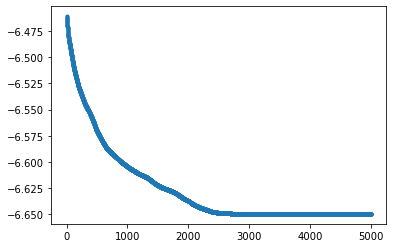

In [78]:
plt.plot(energies, '.-')

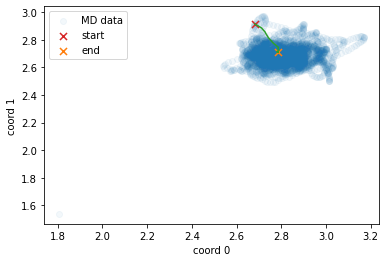

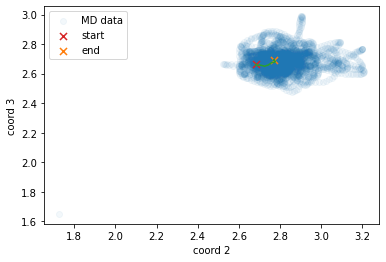

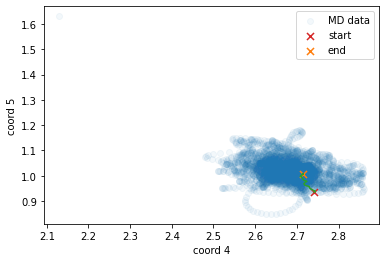

In [98]:
coord1 = 0
coord2 = 1

for (coord1, coord2) in [(0,1), (2,3), (4,5)]:
    plt.figure()
    plt.plot(x_opt_s[:, coord1], x_opt_s[:, coord2], '-', c='C2')
    plt.scatter(xis[cis==0, coord1], xis[cis==0, coord2], marker='o', color='C0', alpha=0.05,  label='MD data')
    plt.scatter(x_opt_s[0, coord1], x_opt_s[0, coord2], marker='x', color='C3', label='start', s=50)
    plt.scatter(x_opt_s[-1, coord1], x_opt_s[-1, coord2], marker='x', color='C1', label='end', s=50)
    plt.legend()
    plt.xlabel(f"coord {coord1}")
    plt.ylabel(f"coord {coord2}")



tensor([ 2.7359,  2.7151,  4.5192,  2.7717,  2.7702,  1.0339,  0.5836,  0.6236,
         1.2445,  1.8341,  2.0964, -1.0552], grad_fn=<CloneBackward0>)


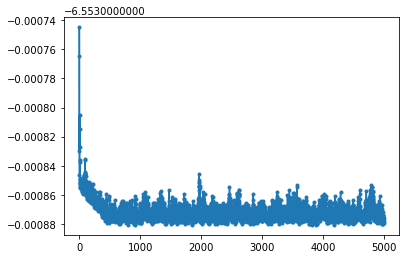

In [124]:
n_steps = 5000
mode_label = 2
mode = mode_label - 1
loss_fn = lambda x: mlp_is2.predict(x)

# start_indx = -3
start_indx = -2
assert cis[start_indx] == mode
x = xis[start_indx].requires_grad_(True)
print(x.clone())

optimizer = torch.optim.Adam([x,], lr=1e-4)

energies = []
x_opt_s = []
for i in range(n_steps):
    optimizer.zero_grad()
    loss = loss_fn(x) 
    loss.backward()
    optimizer.step()
    energies.append(loss.item())
    x_opt_s.append(x.clone().detach())
x_opt_s = torch.stack(x_opt_s)
plt.plot(energies, '.-')

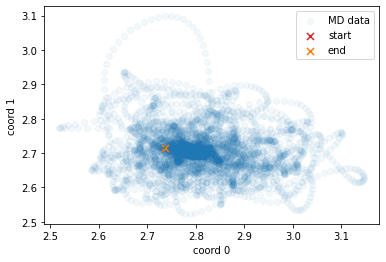

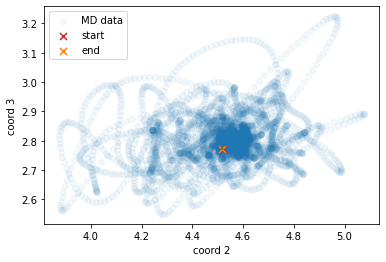

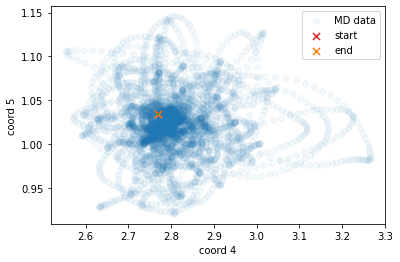

In [125]:
coord1 = 0
coord2 = 1

for (coord1, coord2) in [(0,1), (2,3), (4,5)]:
    plt.figure()
    plt.plot(x_opt_s[:, coord1], x_opt_s[:, coord2], '-', c='C2')
    plt.scatter(xis[cis==mode, coord1], xis[cis==mode, coord2], marker='o', color='C0', alpha=0.05,  label='MD data')
    plt.scatter(x_opt_s[0, coord1], x_opt_s[0, coord2], marker='x', color='C3', label='start', s=50)
    plt.scatter(x_opt_s[-1, coord1], x_opt_s[-1, coord2], marker='x', color='C1', label='end', s=50)
    plt.legend()
    plt.xlabel(f"coord {coord1}")
    plt.ylabel(f"coord {coord2}")


In [108]:
assert cis[start_indx] == 0

AssertionError: 